In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import os
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , f1_score ,auc,roc_auc_score

In [3]:
file=os.path.join('data','final_laliga.csv')
df=pd.read_csv(file)

In [4]:
df.head(10)

,Unnamed: 0,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A
0,0,SP1,2012-08-18,Celta,Malaga,0,1,A,0,0,...,9,8,9,2,0,0,0,2.25,3.25,3.20
1,1,SP1,2012-08-18,Sevilla,Getafe,2,1,H,2,0,...,17,8,8,4,4,0,0,1.62,3.75,5.50
2,2,SP1,2012-08-18,Mallorca,Espanol,2,1,H,1,1,...,14,7,4,3,2,0,0,2.00,3.30,3.80
3,3,SP1,2012-08-19,Real Madrid,Valencia,1,1,D,1,1,...,16,12,5,1,4,0,0,1.25,6.00,10.00
4,4,SP1,2012-08-19,Ath Bilbao,Betis,3,5,A,0,3,...,17,11,4,2,2,0,0,1.83,3.50,4.20
5,5,SP1,2012-08-19,Levante,Ath Madrid,1,1,D,1,1,...,7,3,6,2,1,0,0,3.20,3.40,2.20
6,6,SP1,2012-08-19,Barcelona,Sociedad,5,1,H,4,1,...,12,9,1,2,3,0,0,1.10,9.00,26.00
7,7,SP1,2012-08-20,La Coruna,Osasuna,2,0,H,0,0,...,13,5,7,3,4,0,0,2.00,3.40,3.75
8,8,SP1,2012-08-20,Vallecano,Granada,1,0,H,0,0,...,9,3,5,2,0,0,0,2.20,3.30,3.30
9,9,SP1,2012-08-20,Zaragoza,Valladolid,0,1,A,0,1,...,14,4,4,2,5,0,0,2.15,3.30,3.40


In [17]:
rating={}
k_factor=[]
home_elo_before=[]
away_elo_before=[]
home_elo_after=[]
away_elo_after=[]
Home_advantage=50

def get_k(games_played):

    if games_played<10:
        return 40
    elif games_played <30:
        return 30
    else:
        return 20

def convert_result_to_proper_elo(encoded_result):
    """
    Convert encoded result to elo score from home teams perceptive
    assuming A=0,D=1,H=2
    return:0(loss),0.5(draw),1(win)
    """
    if encoded_result == 0:
        return 0
    elif encoded_result==1:
        return 0.5
    elif encoded_result==2:
        return 1
    else:
        raise ValueError(f'Unexpected result value:{encoded_result}')

games_played={}
for index , row in df.iterrows():
    home=row['HomeTeam']
    away=row['AwayTeam']
    encoded_result=row['FTR_Encoded']
    result=convert_result_to_proper_elo(encoded_result)
    
    rh=rating.setdefault(home,1500)
    ra=rating.setdefault(away,1500)
    
    games_played.setdefault(home,0)
    games_played.setdefault(away,0)
    
    rh_adjusted=rh+Home_advantage
    home_elo_before.append(rh)
    away_elo_before.append(ra)
    eh=1/(1+10**((ra-rh_adjusted)/400))
    ea=1-eh
    k_home=get_k(games_played[home])
    k_away=get_k(games_played[away])
    k=(k_home+k_away)/2
    k_factor.append(k)
    

    
    rh_new=rh+k*(result-eh)
    ra_new=ra+k*((1-result)-(1-eh))
    
    rating[home]=rh_new
    rating[away]=ra_new
    games_played[home]+=1
    games_played[away]+=1
    home_elo_after.append(rh_new)
    away_elo_after.append(ra_new)

df['home_elo_before']=home_elo_before
df['away_elo_before']=away_elo_before
df['home_elo_after']=home_elo_after
df['away_elo_after']=away_elo_after
df['k_factor']=k_factor

for team, elo in sorted(rating.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{team}: {elo:.0f} (played {games_played[team]} games)")

df['elo_diff']=df['home_elo_before']-df['away_elo_before']
print(df['elo_diff'])


Real Madrid: 1776 (played 494 games)
Barcelona: 1775 (played 494 games)
Ath Madrid: 1694 (played 494 games)
Ath Bilbao: 1654 (played 494 games)
Villarreal: 1652 (played 456 games)
Betis: 1607 (played 456 games)
Osasuna: 1553 (played 342 games)
Celta: 1546 (played 494 games)
Sociedad: 1532 (played 494 games)
Valencia: 1532 (played 494 games)
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
           ...    
4935    237.137759
4936     67.898319
4937   -103.564337
4938    157.228142
4939   -170.809318
Name: elo_diff, Length: 4940, dtype: float64


In [18]:
import trueskill
from trueskill import Rating , rate_1vs1
env=trueskill.TrueSkill(draw_probability=0.25)

In [ ]:
ts_rating={}
home_mu=[]
away_mu=[]
home_sigma=[]
away_sigma=[]
for index , row in df.iterrows():
    home=row['HomeTeam']
    away=row['AwayTeam']
    result=row['FTR_Encoded']
    ts_rating.setdefault(home,Rating()) #mu = 25 and sigma=8.33
    ts_rating.setdefault(away,Rating())
    r_home=ts_rating[home]
    r_away=ts_rating[away]
    home_mu.append(r_home.mu)
    away_mu.append(r_away.mu)
    home_sigma.append(r_home.sigma)
    away_sigma.append(r_away.sigma)

    if result==2:
        ts_rating[home],ts_rating[away]=rate_1vs1(r_home,r_away)
    elif result==0:
        ts_rating[away],ts_rating[home]=rate_1vs1(r_away,r_home)
    else:
        ts_rating[home],ts_rating[away]=rate_1vs1(r_home,r_away,drawn=True)

df['ts_home_mu']=home_mu
df['ts_away_mu']=away_mu
df['ts_home_sigma']=home_sigma
df['ts_away_sigma']=away_sigma
df['ts_mu_diff']=df['ts_home_mu']-df['ts_away_mu']
df['ts_sigma_diff']=df['ts_home_sigma']-df['ts_away_sigma']
df['ts_conservative_diff']=(
    (df['ts_home_mu']-3*df['ts_home_sigma'])-
    (df['ts_away_mu']-3*df['ts_away_sigma'])
)

In [ ]:
from glicko2 import Player
glicko={}
g_home_rating=[]
g_away_rating=[]
g_home_rd=[]
g_away_rd=[]
def glicko_result(encode):
    if encode==2:
        return 1
    elif encode==1:
        return 0.5
    else:
        return 0

for index , row in df.iterrows():
    home=row['HomeTeam']
    away=row['AwayTeam']
    result=glicko_result(row['FTR_Encoded'])
    glicko.setdefault(home,Player()) #rating =1500 and rd=350
    glicko.setdefault(away,Player())
    h=glicko[home]
    a=glicko[away]
    g_home_rating.append(h.rating)
    g_away_rating.append(a.rating)
    g_home_rd.append(h.rd)
    g_away_rd.append(a.rd)
    h.update_player([a.rating],[a.rd],[result])
    a.update_player([h.rating],[h.rd],[1-result])

df["glicko_home_rating"] = g_home_rating
df["glicko_away_rating"] = g_away_rating
df["glicko_home_rd"] = g_home_rd
df["glicko_away_rd"] = g_away_rd

df["glicko_diff"] = df["glicko_home_rating"] - df["glicko_away_rating"]


<Axes: xlabel='elo_diff', ylabel='Count'>

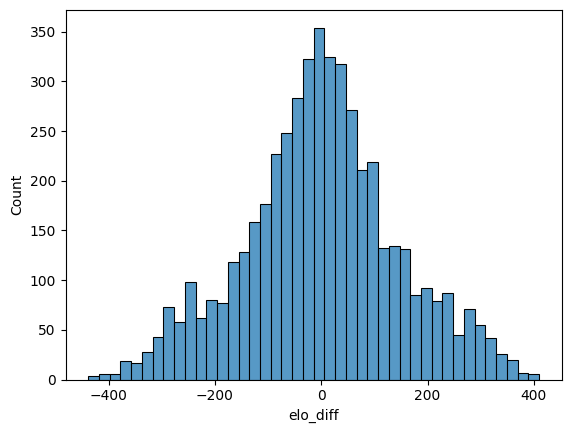

In [21]:
sns.histplot(df['elo_diff'])

In [22]:
df.head()

,Unnamed: 0,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,ts_home_sigma,ts_away_sigma,ts_mu_diff,ts_sigma_diff,ts_conservative_diff,glicko_home_rating,glicko_away_rating,glicko_home_rd,glicko_away_rd,glicko_diff
0,0,SP1,2012-08-18,Celta,Malaga,0,1,A,0,0,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0
1,1,SP1,2012-08-18,Sevilla,Getafe,2,1,H,2,0,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0
2,2,SP1,2012-08-18,Mallorca,Espanol,2,1,H,1,1,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0
3,3,SP1,2012-08-19,Real Madrid,Valencia,1,1,D,1,1,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0
4,4,SP1,2012-08-19,Ath Bilbao,Betis,3,5,A,0,3,...,8.333333,8.333333,0.0,0.0,0.0,1500.0,1500.0,350.0,350.0,0.0


<Axes: xlabel='elo_diff', ylabel='FTR_Encoded'>

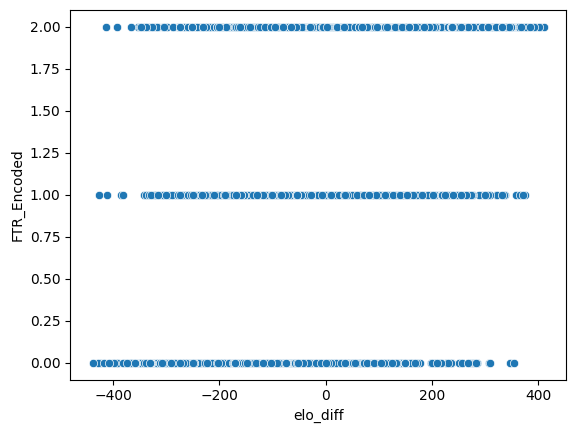

In [23]:
sns.scatterplot(x=df['elo_diff'],y=df['FTR_Encoded'])

In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:

Y_Encoder=LabelEncoder()

In [26]:
Y=Y_Encoder.fit_transform(df['FTR'])

In [27]:
Y

array([0, 2, 2, ..., 0, 2, 0], shape=(4940,))

In [28]:
df['FTR_Encoded']=Y

In [29]:
Y_Encoder.inverse_transform([0,1,2])

array(['A', 'D', 'H'], dtype=object)

In [30]:
df.isna().sum()

Unnamed: 0              0
Div                     0
Date                    0
HomeTeam                0
AwayTeam                0
FTHG                    0
FTAG                    0
FTR                     0
HTHG                    0
HTAG                    0
HTR                     0
HS                      0
AS                      0
HST                     0
AST                     0
HF                      0
AF                      0
HC                      0
AC                      0
HY                      0
AY                      0
HR                      0
AR                      0
B365H                   0
B365D                   0
B365A                   0
FTR_Encoded             0
home_elo_before         0
away_elo_before         0
home_elo_after          0
away_elo_after          0
k_factor                0
elo_diff                0
ts_home_mu              0
ts_away_mu              0
ts_home_sigma           0
ts_away_sigma           0
ts_mu_diff              0
ts_sigma_dif

In [31]:
from sklearn.model_selection import train_test_split
df.columns

Index(['Unnamed: 0', 'Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG',
       'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
       'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A',
       'FTR_Encoded', 'home_elo_before', 'away_elo_before', 'home_elo_after',
       'away_elo_after', 'k_factor', 'elo_diff', 'ts_home_mu', 'ts_away_mu',
       'ts_home_sigma', 'ts_away_sigma', 'ts_mu_diff', 'ts_sigma_diff',
       'ts_conservative_diff', 'glicko_home_rating', 'glicko_away_rating',
       'glicko_home_rd', 'glicko_away_rd', 'glicko_diff'],
      dtype='str')

In [32]:
df['home_win']=(df['FTR']=='H').astype(int)
df['Away_win']=(df['FTR']=='A').astype(int)


In [33]:
df['home_point_last5']=df.groupby('HomeTeam')['home_win'].transform(lambda x:x.shift(1).rolling(5,min_periods=1).mean())
df['away_point_last5']=df.groupby('AwayTeam')['Away_win'].transform(lambda x:x.shift(1).rolling(5,min_periods=1).mean())
df['form']=df['home_point_last5']-df['away_point_last5']
df=df.dropna()

In [34]:
X=df[['B365H','B365A','B365D','home_elo_before','away_elo_before','elo_diff', 'ts_home_mu', 'ts_away_mu','ts_home_sigma', 'ts_away_sigma', 'ts_mu_diff', 'ts_sigma_diff','ts_conservative_diff', 'glicko_home_rating', 'glicko_away_rating','glicko_home_rd', 'glicko_away_rd', 'glicko_diff','home_point_last5','away_point_last5','form']]
Z=(df['FTR_Encoded']==2)
X_train,X_test,Y_train,Y_test=train_test_split(X,Z,test_size=0.2)

In [42]:
from sklearn.ensemble import GradientBoostingClassifier , RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBRFClassifier 
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier

In [49]:
clk1=GradientBoostingClassifier(n_estimators=200,learning_rate=0.1,max_depth=5,random_state=42)
#clk1=LGBMClassifier(n_estimators=200,learning_rate=0.1,max_depth=5,random_state=42)
calibrated=CalibratedClassifierCV(clk1,method='isotonic',cv=5)


In [50]:
calibrated.fit(X_train,Y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",GradientBoost...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_esti

In [51]:
y_pred=calibrated.predict(X_test)

In [52]:
accuracy_score(Y_test,y_pred)

0.6469387755102041

In [54]:
df['FTR'].value_counts()

FTR
H    2249
A    1407
D    1241
Name: count, dtype: int64

In [53]:
print(classification_report(y_pred,Y_test))

print(roc_auc_score(y_pred,Y_test),"roc_auc")

              precision    recall  f1-score   support

       False       0.77      0.65      0.71       638
        True       0.50      0.64      0.56       342

    accuracy                           0.65       980
   macro avg       0.63      0.65      0.63       980
weighted avg       0.68      0.65      0.65       980

0.6454105483143595 roc_auc


In [ ]:
y_proba=calibrated.predict_proba(X_test)

confidence=y_proba.max(axis=1)


In [ ]:
base = calibrated.calibrated_classifiers_[0].estimator
feature=base.feature_importances_

features_imp=pd.DataFrame({
    'feature':X_train.columns,
    'importance':feature
}).sort_values('importance',ascending=False)
print(features_imp)

                 feature  importance
0                  B365H    0.136211
1                  B365A    0.135260
15        glicko_home_rd    0.058176
16        glicko_away_rd    0.053903
6             ts_home_mu    0.048908
3        home_elo_before    0.048433
8          ts_home_sigma    0.047426
5               elo_diff    0.044112
10            ts_mu_diff    0.042536
7             ts_away_mu    0.041977
11         ts_sigma_diff    0.041325
12  ts_conservative_diff    0.040468
14    glicko_away_rating    0.039738
13    glicko_home_rating    0.038920
2                  B365D    0.038316
4        away_elo_before    0.037477
9          ts_away_sigma    0.033301
17           glicko_diff    0.030313
20                  form    0.018953
19      away_point_last5    0.014005
18      home_point_last5    0.010242


In [ ]:
# Check what Y_test actually is
print(f"Y_test type: {type(Y_test)}")
print(f"Y_test shape: {Y_test.shape}")
print(f"Y_test first few values:\n{Y_test.head()}")

# If it's a Series, check if it contains tuples or arrays
print(f"First element type: {type(Y_test.iloc[0])}")
print(f"First element: {Y_test.iloc[0]}")

Y_test type: <class 'pandas.core.series.Series'>
Y_test shape: (980,)
Y_test first few values:
223     False
3427     True
4368    False
704     False
1495     True
Name: FTR_Encoded, dtype: bool
First element type: <class 'numpy.bool_'>
First element: False


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

# Convert boolean to numeric (True->1, False->0)
y_test_numeric = Y_test.astype(int)

# Now calculate metrics
y_pred_proba = calibrated.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test_numeric, y_pred_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_test_numeric, calibrated.predict(X_test)):.4f}")

# Test without betting odds to check for leakage
X_test_no_odds = X_test.drop(['B365H', 'B365A', 'B365D'], axis=1)
X_train_no_odds = X_train.drop(['B365H', 'B365A', 'B365D'], axis=1)

clk2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, 
                                    max_depth=5, random_state=42)
calibrated2 = CalibratedClassifierCV(clk2, method='isotonic', cv=5)
calibrated2.fit(X_train_no_odds, Y_train.astype(int))

y_pred_no_odds = calibrated2.predict_proba(X_test_no_odds)[:, 1]
print(f"\nROC-AUC without odds: {roc_auc_score(y_test_numeric, y_pred_no_odds):.4f}")
print(f"Accuracy without odds: {accuracy_score(y_test_numeric, calibrated2.predict(X_test_no_odds)):.4f}")

ROC-AUC: 0.7133
Accuracy: 0.6582

ROC-AUC without odds: 0.6971
Accuracy without odds: 0.6388


In [ ]:
# Test without betting odds
X_test_no_odds = X_test.drop(['B365H', 'B365A', 'B365D'], axis=1)
X_train_no_odds = X_train.drop(['B365H', 'B365A', 'B365D'], axis=1)

clk2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, 
                                    max_depth=5, random_state=42)
calibrated2 = CalibratedClassifierCV(clk2, method='isotonic', cv=5)
calibrated2.fit(X_train_no_odds, Y_train.astype(int))

y_pred_no_odds = calibrated2.predict_proba(X_test_no_odds)[:, 1]
y_test_numeric = Y_test.astype(int)

print(f"ROC-AUC without odds: {roc_auc_score(y_test_numeric, y_pred_no_odds):.4f}")
print(f"Accuracy without odds: {accuracy_score(y_test_numeric, calibrated2.predict(X_test_no_odds)):.4f}")

# Compare
print(f"\nPerformance drop:")
print(f"ROC-AUC drop: {0.7064 - roc_auc_score(y_test_numeric, y_pred_no_odds):.4f}")
print(f"Accuracy drop: {0.6398 - accuracy_score(y_test_numeric, calibrated2.predict(X_test_no_odds)):.4f}")

ROC-AUC without odds: 0.6971
Accuracy without odds: 0.6388

Performance drop:
ROC-AUC drop: 0.0093
Accuracy drop: 0.0010


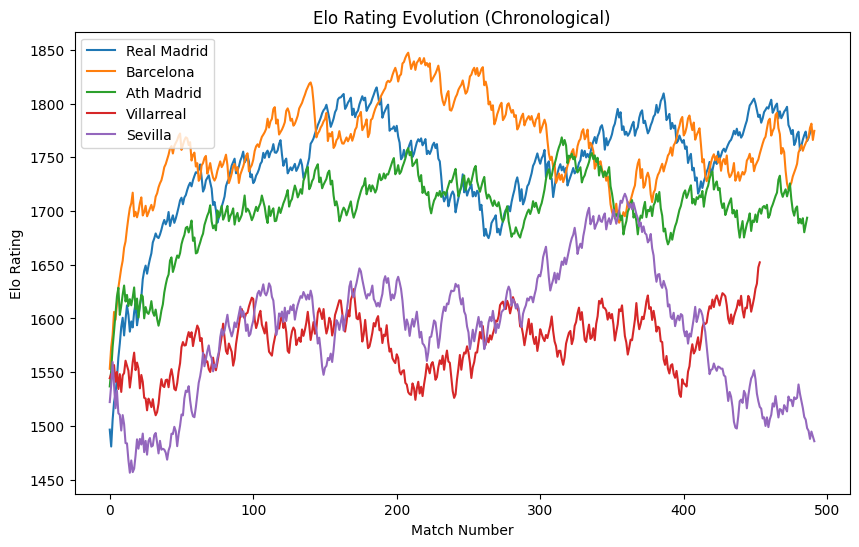

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

teams_to_plot = ['Real Madrid', 'Barcelona', 'Ath Madrid','Villarreal','Sevilla']

plt.figure(figsize=(10, 6))

for team in teams_to_plot:
    
    # Home matches
    home = df[df['HomeTeam'] == team][
        ['Date', 'home_elo_after']
    ].rename(columns={'home_elo_after': 'elo'})
    
    # Away matches
    away = df[df['AwayTeam'] == team][
        ['Date', 'away_elo_after']
    ].rename(columns={'away_elo_after': 'elo'})
    
    # Combine + sort by date
    team_data = pd.concat([home, away]).sort_values('Date')
    
    # Plot
    plt.plot(team_data['elo'].values, label=team)

plt.xlabel('Match Number')
plt.ylabel('Elo Rating')
plt.title('Elo Rating Evolution (Chronological)')
plt.legend()
plt.show()


##visualization !!!


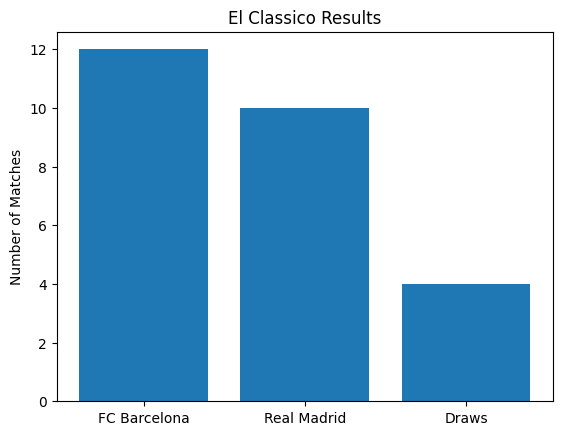

In [123]:
real_madrid='Real Madrid'
barca='Barcelona'
matches = df[
((df['HomeTeam']==real_madrid) & (df['AwayTeam']==barca)) |
((df['AwayTeam']==real_madrid) & (df['HomeTeam']==barca))
]
Barca_won=0
Real_Madrid_won=0
draws=0
for index, row in matches.iterrows():
    if row['FTR']=='D':
        draws += 1
    elif row['HomeTeam']== 'Barcelona' and row['FTR']=='H':
        Barca_won += 1 
    elif row['AwayTeam']=='Barcelona' and row['FTR']=='A':
        Barca_won+=1
    else:
        Real_Madrid_won=Real_Madrid_won+1
teams=['FC Barcelona','Real Madrid','Draws']
results=[Barca_won,Real_Madrid_won,draws]
plt.bar(teams,results)
plt.title('El Classico Results')
plt.ylabel('Number of Matches')
plt.show()

In [124]:
for index,row in matches.iterrows():
    home=row['HomeTeam']
    away=row['AwayTeam']
    result=row['FTR']
    home_goal=row['FTHG']
    away_goal=row['FTAG']
    if result=='H':
        winner=home
    elif result=='A':
        winner=away
    else:
        winner='Draw'
    print(f'{winner}')

Draw
Real Madrid
Barcelona
Barcelona
Real Madrid
Barcelona
Barcelona
Real Madrid
Draw
Barcelona
Barcelona
Draw
Barcelona
Barcelona
Draw
Real Madrid
Real Madrid
Real Madrid
Real Madrid
Barcelona
Real Madrid
Barcelona
Real Madrid
Real Madrid
Barcelona
Barcelona


In [125]:
print(len(df),"len df")
print(len(X_train))
print(len(X_test))
df['Date'].min()  , df['Date'].max()
print(df['home_win'].value_counts(),'home win')
print(df['home_win'].mean(),'home win avg')

4897 len df
3917
980
home_win
0    2648
1    2249
Name: count, dtype: int64 home win
0.459260771901164 home win avg


In [126]:
print(type(clk1).__name__)
print(type(calibrated).__name__)
print(clk1.n_estimators,'estimators')
print(clk1.max_depth,'max_depth')
print(clk1.learning_rate,'learning_rate')
print(clk1.min_samples_split,'min split')

GradientBoostingClassifier
CalibratedClassifierCV
200 estimators
5 max_depth
0.1 learning_rate
2 min split


In [129]:
y_proba_pos = y_proba[:, 1]   # class 1 confidence

print("=== CONFIDENCE STRATIFIED ===")
for thresh in [0.5, 0.55, 0.6, 0.65, 0.7]:
    mask = y_proba_pos >= thresh
    if mask.sum() > 0:
        acc = accuracy_score(Y_test[mask], y_pred[mask])
        cov = mask.sum() / len(Y_test)
        print(f"Threshold ≥{thresh:.0%}: Acc={acc:.1%}, Coverage={cov:.1%}")


=== CONFIDENCE STRATIFIED ===
Threshold ≥50%: Acc=68.7%, Coverage=35.8%
Threshold ≥55%: Acc=72.7%, Coverage=25.8%
Threshold ≥60%: Acc=78.6%, Coverage=20.5%
Threshold ≥65%: Acc=80.8%, Coverage=15.4%
Threshold ≥70%: Acc=83.6%, Coverage=11.2%


In [136]:
# Test each rating system individually
from sklearn.metrics import accuracy_score

# Elo only
X_elo = X_train[['home_elo_before', 'away_elo_before', 'elo_diff']]
model_elo = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
model_elo.fit(X_elo, Y_train)
acc_elo = accuracy_score(Y_test, model_elo.predict(X_test[['home_elo_before', 'away_elo_before', 'elo_diff']]))

# Elo + TrueSkill
X_elo_ts = X_train[['home_elo_before', 'away_elo_before', 'elo_diff', 
                     'ts_home_mu', 'ts_away_mu', 'ts_home_sigma', 'ts_away_sigma',
                     'ts_mu_diff', 'ts_sigma_diff', 'ts_conservative_diff']]
model_elo_ts = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
model_elo_ts.fit(X_elo_ts, Y_train)
acc_elo_ts = accuracy_score(Y_test, model_elo_ts.predict(X_test[X_elo_ts.columns]))

# Elo + TrueSkill + Glicko
X_elo_ts_glicko = X_train[['home_elo_before', 'away_elo_before', 'elo_diff',
                            'ts_home_mu', 'ts_away_mu', 'ts_home_sigma', 'ts_away_sigma',
                            'ts_mu_diff', 'ts_sigma_diff', 'ts_conservative_diff',
                            'glicko_home_rating', 'glicko_away_rating', 'glicko_home_rd',
                            'glicko_away_rd', 'glicko_diff']]
model_elo_ts_glicko = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
model_elo_ts_glicko.fit(X_elo_ts_glicko, Y_train)
acc_elo_ts_glicko = accuracy_score(Y_test, model_elo_ts_glicko.predict(X_test[X_elo_ts_glicko.columns]))

# Odds only
X_odds_train = X_train[['B365H', 'B365D', 'B365A']]
X_odds_test  = X_test[['B365H', 'B365D', 'B365A']]

model_odds = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1
)

model_odds.fit(X_odds_train, Y_train)

y_pred_odds = model_odds.predict(X_odds_test)
acc_odds = accuracy_score(Y_test, y_pred_odds)

print("=== ABLATION STUDY ===")
print(f"Elo only: {acc_elo:.3f}")
print(f"Elo + TrueSkill: {acc_elo_ts:.3f}")
print(f"Elo + TrueSkill + Glicko: {acc_elo_ts_glicko:.3f}")
print(f"Odds only: {acc_odds:.3f}")
print(f"Full model (all features): {accuracy_score(Y_test, y_pred):.3f}")


=== ABLATION STUDY ===
Elo only: 0.601
Elo + TrueSkill: 0.602
Elo + TrueSkill + Glicko: 0.626
Odds only: 0.637
Full model (all features): 0.658


In [139]:
# Which teams are hardest to predict?
import pandas as pd

results_df = pd.DataFrame({
    'actual': Y_test,
    'predicted': y_pred,
    'correct': Y_test == y_pred
})

# Get team names from test set (you need to align with X_test indices)
# Assuming you have team names stored somewhere
test_indices = X_test.index
test_teams = df.loc[test_indices, 'HomeTeam']

results_df['team'] = test_teams.values

team_accuracy = results_df.groupby('team')['correct'].agg(['sum', 'count', 'mean']).sort_values('mean')

print("=== HARDEST TO PREDICT (Bottom 5) ===")
print(team_accuracy.head(5))

print("\n=== EASIEST TO PREDICT (Top 5) ===")
print(team_accuracy.tail(5))

=== HARDEST TO PREDICT (Bottom 5) ===
          sum  count      mean
team                          
Malaga     10     26  0.384615
Sevilla    32     63  0.507937
Eibar      16     31  0.516129
Sociedad   31     59  0.525424
Mallorca   10     19  0.526316

=== EASIEST TO PREDICT (Top 5) ===
             sum  count      mean
team                             
Real Madrid   42     48  0.875000
Almeria        8      9  0.888889
Cadiz         12     13  0.923077
Cordoba        4      4  1.000000
Zaragoza       3      3  1.000000


In [143]:
from sklearn.calibration import calibration_curve

y_proba_pos = y_proba[:, 1]   # take positive class

prob_true, prob_pred = calibration_curve(
    Y_test,
    y_proba_pos,
    n_bins=10
)

print("=== CALIBRATION CURVE ===")
for i, (true, pred) in enumerate(zip(prob_true, prob_pred)):
    print(f"Bin {i+1}: Predicted={pred:.3f}, Actual={true:.3f}")


=== CALIBRATION CURVE ===
Bin 1: Predicted=0.087, Actual=0.000
Bin 2: Predicted=0.174, Actual=0.323
Bin 3: Predicted=0.250, Actual=0.210
Bin 4: Predicted=0.349, Actual=0.365
Bin 5: Predicted=0.445, Actual=0.444
Bin 6: Predicted=0.541, Actual=0.553
Bin 7: Predicted=0.647, Actual=0.725
Bin 8: Predicted=0.743, Actual=0.797
Bin 9: Predicted=0.847, Actual=0.893
Bin 10: Predicted=0.928, Actual=1.000


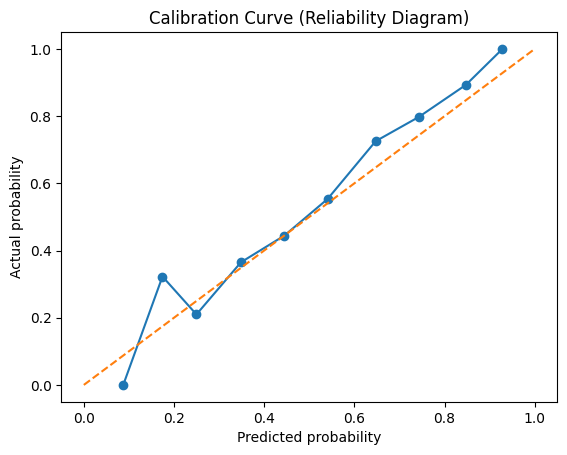

In [145]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Use positive class probability (class 1)
y_proba_pos = y_proba[:, 1]

prob_true, prob_pred = calibration_curve(
    Y_test,
    y_proba_pos,
    n_bins=10
)

# Plot calibration curve
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve (Reliability Diagram)")
plt.show()


In [146]:
import os
print(os.getcwd())


C:\Users\Asus\Desktop\ML\project


In [149]:
# Training history (if you saved it during training)
# If not, run this:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1),
    X_train, Y_train, cv=5, n_jobs=-1,
    train_sizes=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    scoring='accuracy'
)

print("=== LEARNING CURVES ===")
print("Train sizes:", train_sizes)
print("Train scores (mean):", train_scores.mean(axis=1))
print("Val scores (mean):", val_scores.mean(axis=1))



=== LEARNING CURVES ===
Train sizes: [ 313  939 1566 2193 2819 3133]
Train scores (mean): [1.         1.         0.99872286 0.99060648 0.97523945 0.95869773]
Val scores (mean): [0.60709562 0.61961419 0.63109801 0.63135214 0.64386289 0.64590077]


In [155]:
incorrect_mask = Y_test != y_pred

incorrect_df = X_test[incorrect_mask].copy()
incorrect_df['actual'] = Y_test[incorrect_mask]
incorrect_df['predicted'] = y_pred[incorrect_mask]
incorrect_df['confidence'] = confidence[incorrect_mask]
print("=== ERROR ANALYSIS ===")
print(f"Total errors: {incorrect_mask.sum()}")

print(f"False positives (pred=1, actual=0): {((y_pred == 1) & (Y_test == 0)).sum()}")
print(f"False negatives (pred=0, actual=1): {((y_pred == 0) & (Y_test == 1)).sum()}")

print("\nErrors by confidence level:")
for thresh in [0.5, 0.6, 0.7]:
    high_conf_errors = incorrect_df[incorrect_df['confidence'] >= thresh]
    print(f"Confidence ≥{thresh:.0%}: {len(high_conf_errors)} errors")

correct_elo_diff = X_test.loc[~incorrect_mask, 'elo_diff'].mean()
incorrect_elo_diff = X_test.loc[incorrect_mask, 'elo_diff'].mean()

print(f"\nAvg Elo diff (correct): {correct_elo_diff:.1f}")
print(f"Avg Elo diff (incorrect): {incorrect_elo_diff:.1f}")


=== ERROR ANALYSIS ===
Total errors: 335
False positives (pred=1, actual=0): 110
False negatives (pred=0, actual=1): 225

Errors by confidence level:
Confidence ≥50%: 335 errors
Confidence ≥60%: 152 errors
Confidence ≥70%: 58 errors

Avg Elo diff (correct): -0.9
Avg Elo diff (incorrect): 7.9


In [157]:
# Performance by season
# You need season info - extract from dates
test_df = df.loc[X_test.index].copy()
test_df['year'] = pd.to_datetime(test_df['Date']).dt.year
test_df['predicted'] = y_pred
test_df['actual'] = Y_test
test_df['correct'] = Y_test == y_pred

season_performance = test_df.groupby('year')['correct'].agg(['sum', 'count', 'mean'])

print("=== PERFORMANCE BY SEASON ===")
print(season_performance)

=== PERFORMANCE BY SEASON ===
      sum  count      mean
year                      
2012   18     30  0.600000
2013   46     72  0.638889
2014   58     83  0.698795
2015   58     81  0.716049
2016   58     80  0.725000
2017   37     61  0.606557
2018   37     67  0.552239
2019   53     78  0.679487
2020   39     73  0.534247
2021   59     83  0.710843
2022   47     72  0.652778
2023   57     89  0.640449
2024   50     75  0.666667
2025   28     36  0.777778
